# NN Init Geometry — v2: Depth as the Key Variable

## What v1 taught us

The first experiment revealed a fundamental design flaw: **3 layers is too shallow** to expose meaningful differences between init schemes. All non-zero inits produced nearly identical silhouette scores (~0.04–0.06). The geometric divergence between initialization strategies is an **exponential phenomenon** — it compounds with depth. You need at least 10–20 layers to see it clearly.

## Research question (refined)

How does network depth amplify (or suppress) the geometric destruction caused by different weight initializations? Specifically: does the silhouette score at the final layer decay with depth, and does the rate of decay differ significantly across init schemes?

## New hypotheses

- **orthogonal** will preserve separability at any depth (preserves norms exactly)
- **he_normal / kaiming_uniform** will degrade slowly (designed for ReLU variance)
- **random_normal (std=0.01)** will collapse exponentially with depth
- **zeros / constant_small** will produce 100% dead neurons after layer 1
- **sparse** (80% zeros) will collapse faster than he_normal but slower than random_normal

## New metrics

| Metric | Why it matters |
|---|---|
| Silhouette score (post-ReLU) | Class separability in what the next layer actually sees |
| Dead ReLU fraction | % neurons outputting 0 for all inputs — direct measure of information loss |
| Effective rank | Intrinsic dimensionality of the embedding — collapse = rank → 1 |


In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100
os.makedirs('./outputs', exist_ok=True)
print('✓ Imports OK')


✓ Imports OK


In [2]:
CONFIG = {
    'seed': 42,
    'n_samples': 2000,        # larger = more stable silhouette estimates
    'n_features': 30,
    'n_informative': 10,      # richer signal: 10 of 30 features are class-relevant
    'hidden_dim': 256,
    # KEY variable: test these network depths
    'depth_list': [2, 4, 6, 10, 16, 24],
    'pca_sil_components': 50,
    'init_schemes': [
        'random_normal',
        'xavier_uniform',
        'he_normal',
        'kaiming_uniform',
        'orthogonal',
        'lecun_normal',
        'sparse',
        'constant_small',
        'zeros',
    ],
}
print('✓ CONFIG defined')
print(f'  Depths to test: {CONFIG["depth_list"]}')
print(f'  Init schemes: {CONFIG["init_schemes"]}')


✓ CONFIG defined
  Depths to test: [2, 4, 6, 10, 16, 24]
  Init schemes: ['random_normal', 'xavier_uniform', 'he_normal', 'kaiming_uniform', 'orthogonal', 'lecun_normal', 'sparse', 'constant_small', 'zeros']


In [3]:
def set_seeds(seed):
    """Full reproducibility: Python, NumPy, PyTorch, CUDA."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seeds(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Seeds = {CONFIG["seed"]} | Device = {DEVICE}')
print('✓ Cell group 1 complete')


✓ Seeds = 42 | Device = cpu
✓ Cell group 1 complete


## Cell Group 2 — Dataset

Key changes from v1:
- **n_informative=10** (was 2): 10 of 30 features carry genuine class signal. This raises the baseline separability significantly, giving inits more to destroy — or preserve.
- **n_samples=2000**: larger sample → more stable silhouette estimates at each depth.


In [4]:
set_seeds(CONFIG['seed'])
X_raw, y_data = make_classification(
    n_samples=CONFIG['n_samples'],
    n_features=CONFIG['n_features'],
    n_informative=CONFIG['n_informative'],
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,   # moderate separation — not trivially easy
    random_state=CONFIG['seed'],
)
scaler = StandardScaler()
X_data = scaler.fit_transform(X_raw).astype(np.float32)
X_tensor = torch.FloatTensor(X_data).to(DEVICE)
print(f'✓ Dataset: {X_data.shape}, classes: {np.bincount(y_data)}')


✓ Dataset: (2000, 30), classes: [1003  997]


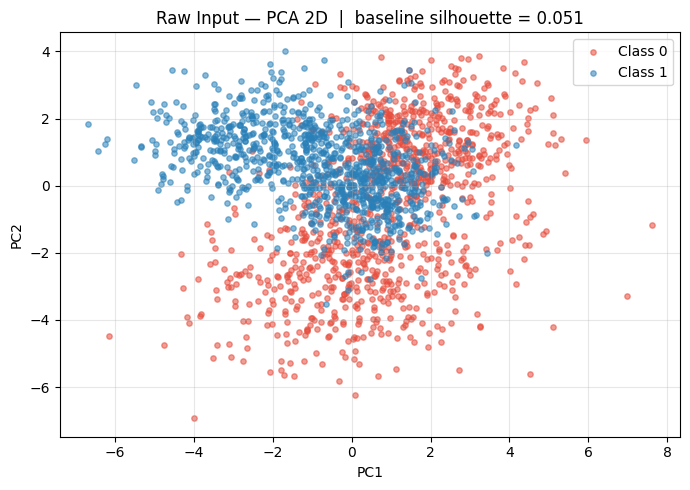

✓ Baseline silhouette (raw input): 0.0511
✓ Cell group 2 complete


In [5]:
# Baseline: silhouette on PCA-50d of raw input
n_comp = min(CONFIG['pca_sil_components'], X_data.shape[1] - 1)
X_pca_base = PCA(n_components=n_comp, random_state=CONFIG['seed']).fit_transform(X_data)
score_baseline = silhouette_score(X_pca_base, y_data)

# Visualise raw data
X_2d_raw = PCA(n_components=2, random_state=CONFIG['seed']).fit_transform(X_data)
fig, ax = plt.subplots(figsize=(7, 5))
for cls, c, lbl in [(0, '#E74C3C', 'Class 0'), (1, '#2980B9', 'Class 1')]:
    m = y_data == cls
    ax.scatter(X_2d_raw[m, 0], X_2d_raw[m, 1], c=c, alpha=0.55, s=15, label=lbl)
ax.set_title(f'Raw Input — PCA 2D  |  baseline silhouette = {score_baseline:.3f}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_00_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Baseline silhouette (raw input): {score_baseline:.4f}')
print('✓ Cell group 2 complete')


## Cell Group 3 — Model and Metric Functions

### Architecture
Same MLP but now **depth is configurable** so we can test 2 → 24 layers with the same codebase.

### Three metrics (all measured on **post-ReLU** activations)

| Metric | Formula / logic |
|---|---|
| `silhouette` | sklearn silhouette_score on PCA-50d embeddings |
| `dead_relu_frac` | fraction of (neuron, sample) pairs where output == 0; if a neuron is dead for all samples, info is permanently lost |
| `effective_rank` | # PCA components needed to explain ≥90% variance; rank→1 means all samples collapsed to a line/point |


In [6]:
class MLP(nn.Module):
    """MLP with variable depth. Returns post-ReLU embeddings per layer."""

    def __init__(self, input_dim, hidden_dim, n_layers):
        super().__init__()
        dims = [input_dim] + [hidden_dim] * n_layers
        self.linears = nn.ModuleList(
            [nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)]
        )
        self.relu = nn.ReLU()

    def get_post_relu_embeddings(self, x):
        """Return dict of post-ReLU activations keyed by 'layer_N'.
        Layer 0 is the raw input (pre-network).
        """
        embs = {'layer_0': x.clone()}
        for i, lin in enumerate(self.linears):
            x = self.relu(lin(x))    # post-ReLU
            embs[f'layer_{i+1}'] = x.clone()
        return embs


def apply_init(model, scheme):
    """Apply named init to all Linear layers. Returns model."""
    for m in model.modules():
        if not isinstance(m, nn.Linear):
            continue
        if scheme == 'random_normal':
            nn.init.normal_(m.weight, 0, 0.01)
        elif scheme == 'xavier_uniform':
            nn.init.xavier_uniform_(m.weight)
        elif scheme == 'he_normal':
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        elif scheme == 'kaiming_uniform':
            nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
        elif scheme == 'orthogonal':
            nn.init.orthogonal_(m.weight)
        elif scheme == 'lecun_normal':
            # LeCun 1998: N(0, 1/fan_in) — designed for tanh, interesting on ReLU
            std = 1.0 / (m.weight.shape[1] ** 0.5)
            nn.init.normal_(m.weight, 0, std)
        elif scheme == 'sparse':
            # 80% of weights are exactly zero, 20% from N(0, 1/fan_in)
            nn.init.sparse_(m.weight, sparsity=0.8)
        elif scheme == 'constant_small':
            nn.init.constant_(m.weight, 0.001)
        elif scheme == 'zeros':
            nn.init.zeros_(m.weight)
        else:
            raise ValueError(scheme)
        nn.init.zeros_(m.bias)
    return model


def compute_metrics(emb_np, y, seed):
    """Compute silhouette, dead_relu_frac, effective_rank from post-ReLU embedding."""
    # dead ReLU fraction: fraction of all (sample, neuron) == 0
    dead_frac = float((emb_np == 0).mean())

    # effective rank: # PCs explaining >= 90% variance
    if np.std(emb_np) < 1e-8:
        return float('nan'), dead_frac, 1
    n_comp = min(emb_np.shape[1], emb_np.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=seed)
    pca.fit(emb_np)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    eff_rank = int(np.searchsorted(cumvar, 0.90)) + 1

    # silhouette on first 50 PCs
    n_sil = min(50, n_comp)
    emb_red = pca.transform(emb_np)[:, :n_sil]
    try:
        sil = float(silhouette_score(emb_red, y))
    except Exception:
        sil = float('nan')

    return sil, dead_frac, eff_rank


print('✓ MLP, apply_init, compute_metrics defined')
print('✓ Cell group 3 complete')


✓ MLP, apply_init, compute_metrics defined
✓ Cell group 3 complete


## Cell Group 4 — Experiment Loop

We sweep over all combinations of **(init scheme × network depth)**. For each combination we record three metrics at the **final layer**: silhouette, dead ReLU fraction, and effective rank. This gives us a 2D surface for each metric.

Runtime note: no training, only forward passes — this is fast even for 24 layers.


In [7]:
# results[scheme][depth] = (silhouette, dead_frac, eff_rank)
results = {s: {} for s in CONFIG['init_schemes']}

# Also track per-layer silhouette at the reference depth (10)
REFERENCE_DEPTH = 10
perlayer_sil = {s: {} for s in CONFIG['init_schemes']}

for depth in CONFIG['depth_list']:
    print(f'\n--- depth={depth} ---')
    for scheme in CONFIG['init_schemes']:
        set_seeds(CONFIG['seed'])
        model = MLP(X_data.shape[1], CONFIG['hidden_dim'], depth).to(DEVICE)
        apply_init(model, scheme)
        model.eval()

        with torch.no_grad():
            embs = model.get_post_relu_embeddings(X_tensor)

        # Metrics at final layer
        final_emb = embs[f'layer_{depth}'].cpu().numpy()
        sil, dead, rank = compute_metrics(final_emb, y_data, CONFIG['seed'])
        results[scheme][depth] = (sil, dead, rank)

        # Per-layer silhouette at reference depth
        if depth == REFERENCE_DEPTH:
            perlayer_sil[scheme] = {}
            for lname, emb_t in embs.items():
                emb_np = emb_t.cpu().numpy()
                s, _, _ = compute_metrics(emb_np, y_data, CONFIG['seed'])
                perlayer_sil[scheme][lname] = s

        sil_str = f'{sil:.3f}' if not (sil != sil) else 'NaN'
        print(f'  {scheme:18s}: sil={sil_str}  dead={dead:.2f}  rank={rank}')

print('\n✓ Cell group 4 (Experiment loop) complete')



--- depth=2 ---
  random_normal     : sil=0.043  dead=0.50  rank=85


  xavier_uniform    : sil=0.039  dead=0.49  rank=87


  he_normal         : sil=0.043  dead=0.50  rank=85


  kaiming_uniform   : sil=0.039  dead=0.49  rank=87


  orthogonal        : sil=0.044  dead=0.50  rank=101


...

  he_normal         : sil=0.021  dead=0.57  rank=14


  kaiming_uniform   : sil=0.006  dead=0.47  rank=19


  orthogonal        : sil=0.015  dead=0.49  rank=27


  lecun_normal      : sil=0.021  dead=0.57  rank=14


  sparse            : sil=NaN  dead=0.48  rank=1
  constant_small    : sil=NaN  dead=0.50  rank=1
  zeros             : sil=NaN  dead=1.00  rank=1

✓ Cell group 4 (Experiment loop) complete


## Cell Group 5 — Visualizations

Six plots — saved to `./outputs/v2_*.png`:

1. **`v2_01_silhouette_vs_depth.png`** — main result: final-layer silhouette vs depth per scheme
2. **`v2_02_dead_relu_vs_depth.png`** — dead neuron fraction vs depth per scheme
3. **`v2_03_effective_rank_vs_depth.png`** — effective rank vs depth per scheme
4. **`v2_04_metrics_heatmaps.png`** — three heatmaps side-by-side (one per metric)
5. **`v2_05_perlayer_at_depth10.png`** — silhouette per layer at depth=10 (replication of v1 but now meaningful)
6. **`v2_06_collapse_portrait.png`** — scatter: dead frac vs silhouette, bubbles sized by rank


In [8]:
COLORS = {
    'random_normal':   '#E74C3C',
    'xavier_uniform':  '#F39C12',
    'he_normal':       '#27AE60',
    'kaiming_uniform': '#1ABC9C',
    'orthogonal':      '#2980B9',
    'lecun_normal':    '#8E44AD',
    'sparse':          '#D35400',
    'constant_small':  '#7F8C8D',
    'zeros':           '#2C3E50',
}
MARKERS = {
    'random_normal': 'o', 'xavier_uniform': 's', 'he_normal': '^',
    'kaiming_uniform': 'D', 'orthogonal': 'P', 'lecun_normal': 'X',
    'sparse': 'v', 'constant_small': 'h', 'zeros': '*',
}
DEPTHS = CONFIG['depth_list']
SCHEMES = CONFIG['init_schemes']
print('✓ Colour palette ready')


✓ Colour palette ready


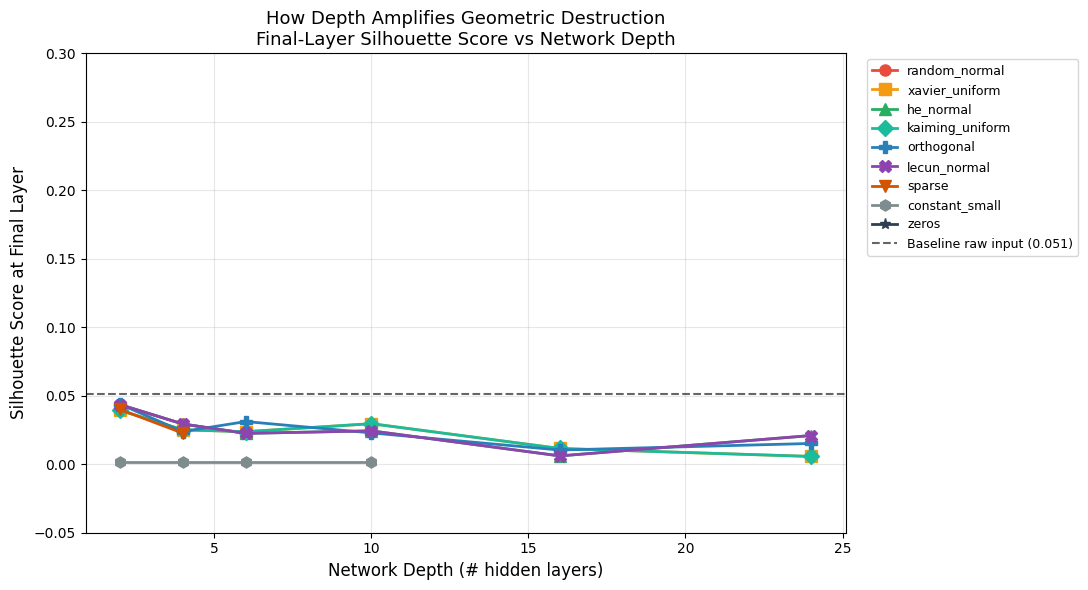

✓ Saved v2_01_silhouette_vs_depth.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for scheme in SCHEMES:
    ys = [results[scheme][d][0] for d in DEPTHS]
    ax.plot(DEPTHS, ys, marker=MARKERS[scheme], color=COLORS[scheme],
            linewidth=2, markersize=8, label=scheme)
ax.axhline(score_baseline, color='black', linestyle='--', alpha=0.6,
           label=f'Baseline raw input ({score_baseline:.3f})')
ax.set_xlabel('Network Depth (# hidden layers)', fontsize=12)
ax.set_ylabel('Silhouette Score at Final Layer', fontsize=12)
ax.set_title('How Depth Amplifies Geometric Destruction\n'
             'Final-Layer Silhouette Score vs Network Depth', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(-0.05, max(score_baseline * 1.3, 0.3))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_01_silhouette_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved v2_01_silhouette_vs_depth.png')


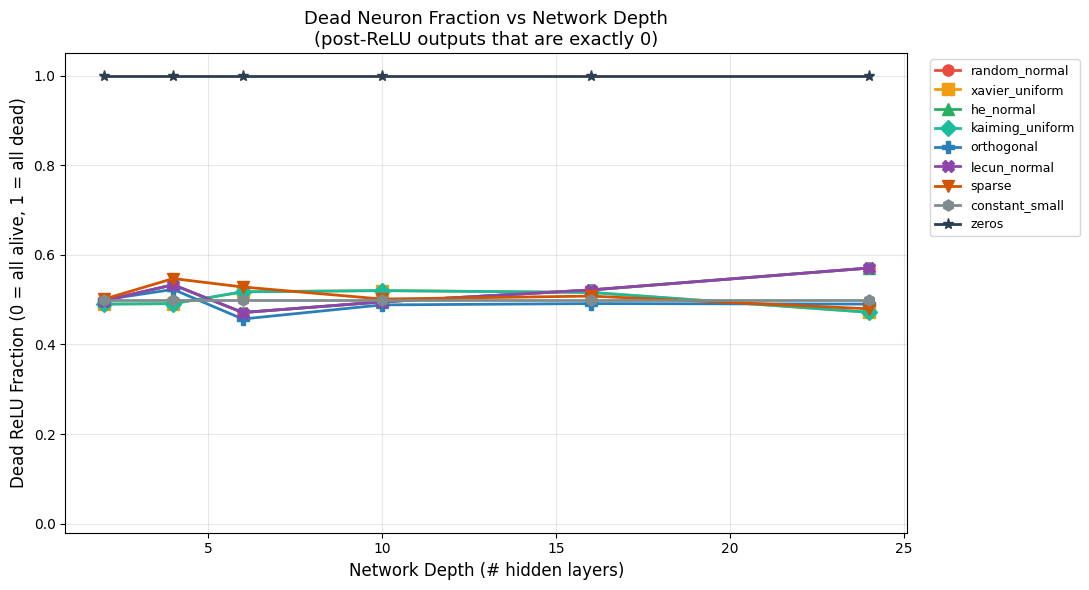

✓ Saved v2_02_dead_relu_vs_depth.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
for scheme in SCHEMES:
    ys = [results[scheme][d][1] for d in DEPTHS]
    ax.plot(DEPTHS, ys, marker=MARKERS[scheme], color=COLORS[scheme],
            linewidth=2, markersize=8, label=scheme)
ax.set_xlabel('Network Depth (# hidden layers)', fontsize=12)
ax.set_ylabel('Dead ReLU Fraction (0 = all alive, 1 = all dead)', fontsize=12)
ax.set_title('Dead Neuron Fraction vs Network Depth\n'
             '(post-ReLU outputs that are exactly 0)', fontsize=13)
ax.set_ylim(-0.02, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_02_dead_relu_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved v2_02_dead_relu_vs_depth.png')


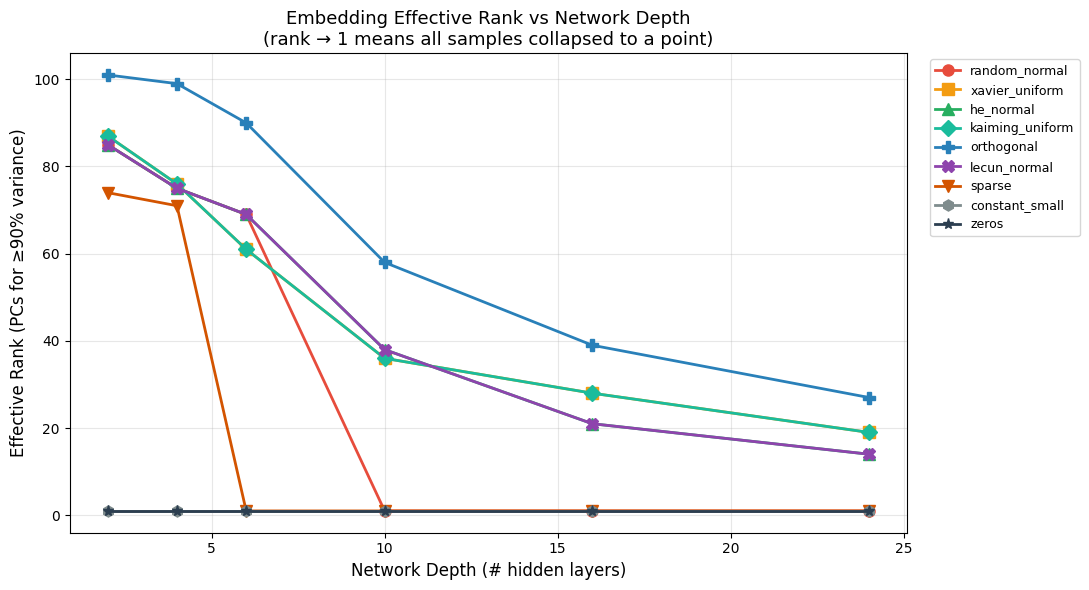

✓ Saved v2_03_effective_rank_vs_depth.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for scheme in SCHEMES:
    ys = [results[scheme][d][2] for d in DEPTHS]
    ax.plot(DEPTHS, ys, marker=MARKERS[scheme], color=COLORS[scheme],
            linewidth=2, markersize=8, label=scheme)
ax.set_xlabel('Network Depth (# hidden layers)', fontsize=12)
ax.set_ylabel('Effective Rank (PCs for ≥90% variance)', fontsize=12)
ax.set_title('Embedding Effective Rank vs Network Depth\n'
             '(rank → 1 means all samples collapsed to a point)', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_03_effective_rank_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved v2_03_effective_rank_vs_depth.png')


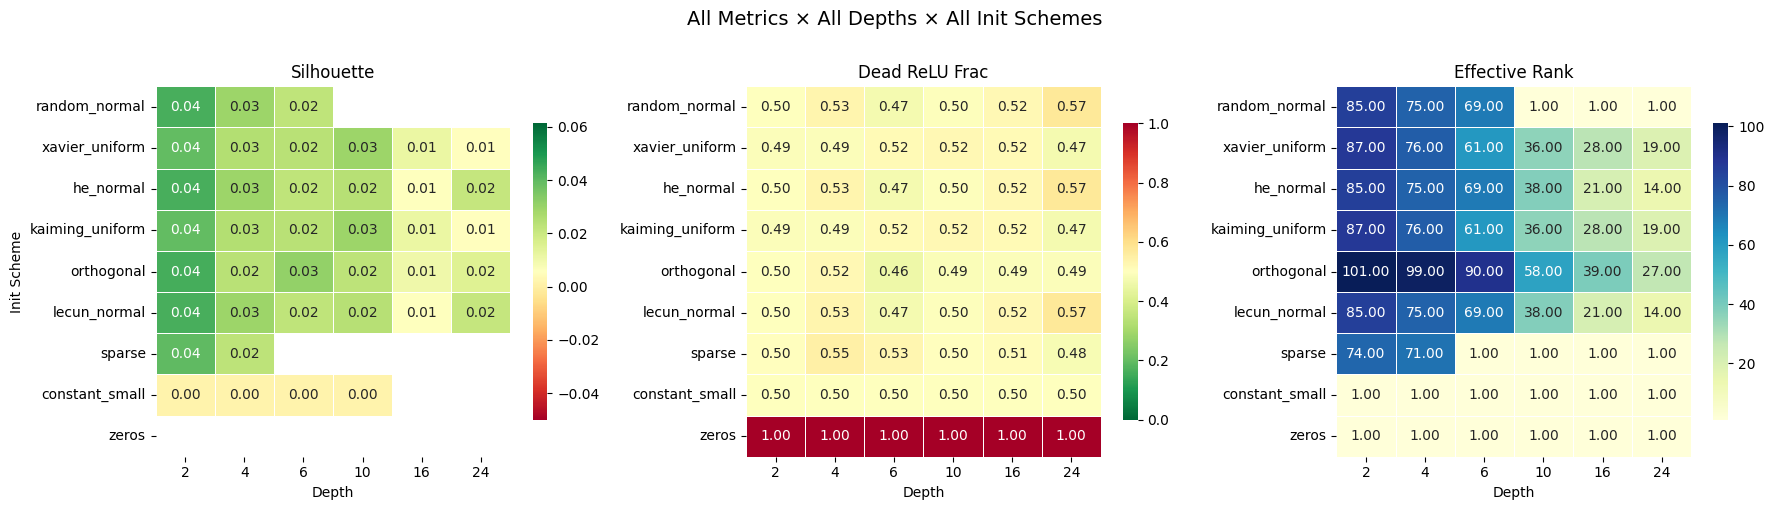

✓ Saved v2_04_metrics_heatmaps.png


In [12]:
metric_names = ['Silhouette', 'Dead ReLU Frac', 'Effective Rank']
metric_idx = [0, 1, 2]
cmaps = ['RdYlGn', 'RdYlGn_r', 'YlGnBu']
vlims = [(-0.05, score_baseline * 1.2), (0, 1), (None, None)]

fig, axes_h = plt.subplots(1, 3, figsize=(18, 5))
for ax_h, mname, midx, cmap, (vmin, vmax) in zip(
        axes_h, metric_names, metric_idx, cmaps, vlims):
    mat = pd.DataFrame(
        {d: [results[s][d][midx] for s in SCHEMES] for d in DEPTHS},
        index=SCHEMES,
    )
    kw = dict(annot=True, fmt='.2f', cmap=cmap, linewidths=0.5,
              ax=ax_h, cbar_kws={'shrink': 0.8})
    if vmin is not None:
        kw['vmin'] = vmin
        kw['vmax'] = vmax
    sns.heatmap(mat.astype(float), **kw)
    ax_h.set_title(mname, fontsize=12)
    ax_h.set_xlabel('Depth')
    ax_h.set_ylabel('Init Scheme' if ax_h is axes_h[0] else '')

fig.suptitle('All Metrics × All Depths × All Init Schemes', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('./outputs/v2_04_metrics_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved v2_04_metrics_heatmaps.png')


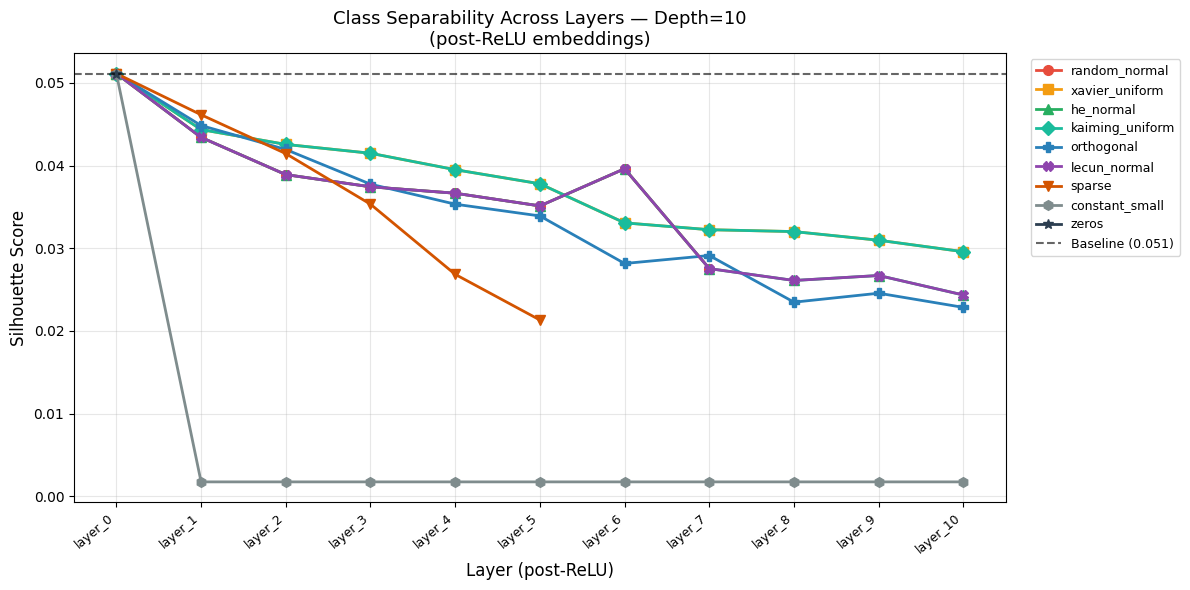

✓ Saved v2_05_perlayer_at_depth10.png


In [13]:
layer_keys = [f'layer_{i}' for i in range(REFERENCE_DEPTH + 1)]
fig, ax = plt.subplots(figsize=(12, 6))
for scheme in SCHEMES:
    ys = [perlayer_sil[scheme].get(k, float('nan')) for k in layer_keys]
    ax.plot(range(len(layer_keys)), ys, marker=MARKERS[scheme],
            color=COLORS[scheme], linewidth=2, markersize=7, label=scheme)
ax.axhline(score_baseline, color='black', linestyle='--', alpha=0.6,
           label=f'Baseline ({score_baseline:.3f})')
ax.set_xticks(range(len(layer_keys)))
ax.set_xticklabels(layer_keys, rotation=40, ha='right', fontsize=9)
ax.set_xlabel('Layer (post-ReLU)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Class Separability Across Layers — Depth={REFERENCE_DEPTH}\n'
             '(post-ReLU embeddings)', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_05_perlayer_at_depth10.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved v2_05_perlayer_at_depth10.png')


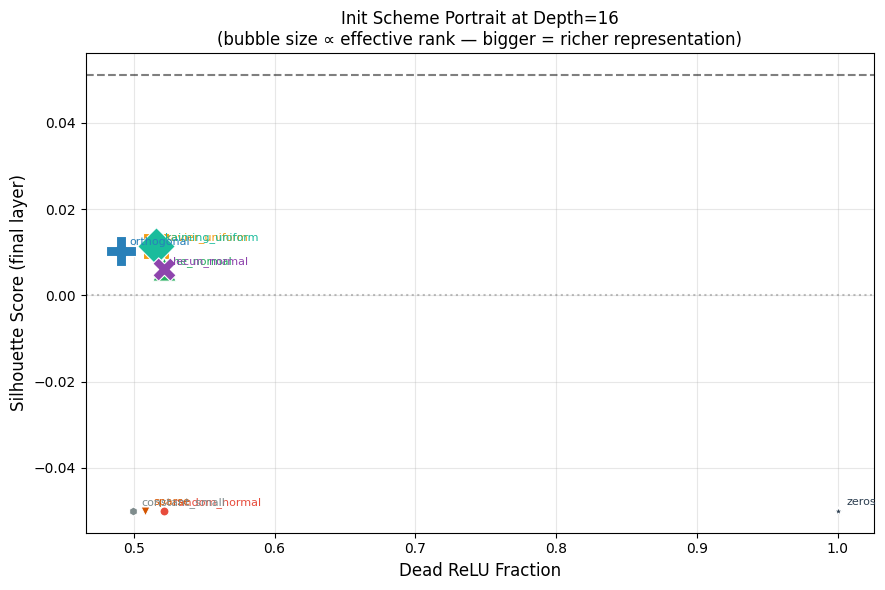

✓ Saved v2_06_collapse_portrait.png
✓ Cell group 5 complete


In [14]:
# Use depth=16 as the 'stress test' depth for this portrait
STRESS_DEPTH = 16
fig, ax = plt.subplots(figsize=(9, 6))
for scheme in SCHEMES:
    sil, dead, rank = results[scheme][STRESS_DEPTH]
    sil_v = sil if sil == sil else -0.05   # place NaN below axis
    ax.scatter(dead, sil_v, s=rank * 12 + 30,
               color=COLORS[scheme], marker=MARKERS[scheme],
               edgecolors='white', linewidth=0.8, zorder=3, label=scheme)
    ax.annotate(scheme, (dead, sil_v), textcoords='offset points',
                xytext=(6, 4), fontsize=8, color=COLORS[scheme])
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(score_baseline, color='black', linestyle='--', alpha=0.5,
           label=f'Baseline ({score_baseline:.3f})')
ax.set_xlabel('Dead ReLU Fraction', fontsize=12)
ax.set_ylabel('Silhouette Score (final layer)', fontsize=12)
ax.set_title(f'Init Scheme Portrait at Depth={STRESS_DEPTH}\n'
             '(bubble size ∝ effective rank — bigger = richer representation)', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/v2_06_collapse_portrait.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved v2_06_collapse_portrait.png')
print('✓ Cell group 5 complete')


## Cell Group 6 — Summary and Findings

Fill in after running:

- **Which init scheme preserves separability to depth 24?** *(orthogonal?)*
- **At what depth does random_normal silhouette cross zero?**
- **Is he_normal better or worse than kaiming_uniform here?** *(they differ only by normal vs uniform sampling — the answer is dataset-dependent)*
- **Does sparse init behave closer to he_normal or to zeros?**
- **Does dead neuron fraction correlate with silhouette?** *(if yes: dead neurons are the proximate cause of geometric collapse)*


In [15]:
rows = []
for s in SCHEMES:
    for d in DEPTHS:
        sil, dead, rank = results[s][d]
        rows.append({'init': s, 'depth': d,
                     'silhouette': round(sil, 4) if sil == sil else float('nan'),
                     'dead_relu': round(dead, 4),
                     'eff_rank': rank})
df = pd.DataFrame(rows)

# Print pivot for silhouette
print('=== Silhouette Score (final layer) ===')
print(df.pivot(index='init', columns='depth', values='silhouette').to_string())

print('\n=== Dead ReLU Fraction ===')
print(df.pivot(index='init', columns='depth', values='dead_relu').to_string())

print('\n=== Effective Rank ===')
print(df.pivot(index='init', columns='depth', values='eff_rank').to_string())

print(f'\nBaseline silhouette (raw input): {score_baseline:.4f}')
print('✓ All done')


=== Silhouette Score (final layer) ===
depth                2       4       6       10      16      24
init                                                           
constant_small   0.0017  0.0017  0.0017  0.0017     NaN     NaN
he_normal        0.0435  0.0293  0.0225  0.0243  0.0061  0.0209
kaiming_uniform  0.0393  0.0251  0.0237  0.0296  0.0115  0.0057
lecun_normal     0.0435  0.0293  0.0225  0.0243  0.0061  0.0209
orthogonal       0.0437  0.0238  0.0311  0.0228  0.0103  0.0151
random_normal    0.0435  0.0293  0.0225     NaN     NaN     NaN
sparse           0.0400  0.0226     NaN     NaN     NaN     NaN
xavier_uniform   0.0393  0.0251  0.0237  0.0296  0.0115  0.0057
zeros               NaN     NaN     NaN     NaN     NaN     NaN

=== Dead ReLU Fraction ===
depth                2       4       6       10      16      24
init                                                           
constant_small   0.4995  0.4995  0.4995  0.4995  0.4995  0.4995
he_normal        0.4974  0.5332  0.47

## Cell Group 7 — Next Steps (from v2)

1. **Add a linear probing accuracy metric**: train a logistic regression on the frozen embeddings. Unlike silhouette, this directly measures how much class-relevant information survives the forward pass — it's also the standard metric in representation learning literature.

2. **Repeat with activation function swap**: replace ReLU with GELU/SiLU/Tanh and re-run. The dead neuron fraction drops to zero for smooth activations — does this change which init scheme 'wins'?

3. **Compare init vs trained network at the same depth**: for each init scheme, run 100 gradient steps and re-measure all three metrics. Does SGD recover collapsed geometry, or does poor init set a permanent ceiling on what the network can represent?
